In [2]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import cdist
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

In [3]:
def remove_redundant_features(data, corr_df, pval_df, corr_threshold, pval_threshold):
    """
    Remove redundant features based on Spearman correlations and p‑values.
    
    Parameters:
      data: pandas DataFrame containing the features.
      corr_df: DataFrame of Spearman correlations (indexed by feature names).
      pval_df: DataFrame of Spearman p‑values with the same indexing as corr_df.
      corr_threshold: float, threshold above which features are considered highly correlated.
      pval_threshold: float, p-value cutoff to consider the correlation significant.
      
    Returns:
      reduced_data: The DataFrame with redundant columns dropped.
      selected_features: List of retained feature names.
    """
    features = list(data.columns)
    to_drop = set()

    for i in range(len(features)):
        for j in range(i + 1, len(features)):
            feat_i = features[i]
            feat_j = features[j]
            corr_val = corr_df.loc[feat_i, feat_j]
            p_val = pval_df.loc[feat_i, feat_j]
            if (abs(corr_val) >= corr_threshold) and (p_val < pval_threshold):
                # In this example, we drop feat_j.
                to_drop.add(feat_j)

    selected_features = [f for f in features if f not in to_drop]
    reduced_data = data[selected_features].copy()

    print("Features dropped due to high correlation ({}):".format(len(to_drop)), to_drop)
    print("Selected features ({}):".format(len(selected_features)), selected_features)
    return reduced_data, selected_features


def manual_feature_drop(data, features_to_drop):
    """
    Drop a list of features from the DataFrame.

    Parameters:
      data: DataFrame containing features.
      features_to_drop: List or set of feature names to drop.

    Returns:
      data_reduced: DataFrame with the specified features removed.
    """
    data_reduced = data.drop(columns=list(features_to_drop), errors='ignore')
    print("Manually dropped features:", features_to_drop)
    return data_reduced


def compute_dunn_index(X, labels):
    """
    Compute the Dunn Index for cluster validation.
    
    Parameters:
      X: Array or matrix of feature values (n_samples x n_features).
      labels: Cluster labels for each sample.
      
    Returns:
      dunn_index: A float, where higher values indicate better clustering.
    """
    unique_labels = np.unique(labels)
    clusters = [X[labels == k] for k in unique_labels]

    # Compute minimum inter-cluster distance
    min_intercluster = np.inf
    for i in range(len(clusters)):
        for j in range(i + 1, len(clusters)):
            distances = cdist(clusters[i], clusters[j], metric='euclidean')
            min_intercluster = min(min_intercluster, distances.min())

    # Compute maximum intra-cluster distance (cluster diameter)
    max_intracluster = 0
    for cluster in clusters:
        if len(cluster) > 1:
            intra_dists = cdist(cluster, cluster, metric='euclidean')
            max_intracluster = max(max_intracluster, intra_dists.max())

    return min_intercluster / max_intracluster if max_intracluster > 0 else np.nan

def plot_silhouette_scores(X, k_range=range(2, 11)):
    """
    Compute and plot silhouette scores for a range of k values using Agglomerative Clustering.
    
    Parameters:
      X: DataFrame or array of numeric features.
      k_range: Iterable of k values (number of clusters) to test.
    
    Returns:
      silhouette_scores: Dictionary mapping k to its silhouette score.
    """
    silhouette_scores = {}

    for k in k_range:
        clustering = AgglomerativeClustering(n_clusters=k)
        labels = clustering.fit_predict(X)
        score = silhouette_score(X, labels)
        silhouette_scores[k] = score

    plt.figure(figsize=(8, 5))
    plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker='o')
    plt.xlabel("Number of clusters")
    plt.ylabel("Silhouette Score")
    plt.title("Silhouette Scores vs. Number of Clusters")
    plt.show()

    return silhouette_scores

def plot_elbow_method(X, k_range=range(1, 11)):
    """
    Compute and plot inertias for KMeans clustering as a measure of the elbow method.
    
    Parameters:
      X: DataFrame or array of numeric features.
      k_range: Iterable of k values (number of clusters) to test.
    
    Returns:
      inertias: Dictionary mapping k to the KMeans inertia.
    """
    inertias = {}

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(X)
        inertias[k] = kmeans.inertia_

    plt.figure(figsize=(8, 5))
    plt.plot(list(inertias.keys()), list(inertias.values()), marker='o')
    plt.xlabel("Number of clusters")
    plt.ylabel("KMeans Inertia")
    plt.title("Elbow Method: Inertia vs. Number of Clusters")
    plt.show()

    return inertias


def plot_multiple_dendrograms(X, countries=None, max_k=10):
    """
    Plot a series of dendrograms (subplots) for k = 1 to max_k.
    
    Parameters:
      X: DataFrame or array of features.
      countries: DataFrame with a "CountryCode" column for leaf labels (optional).
      max_k: Maximum number of clusters (k value) to plot.
    """
    Z = linkage(X, method='ward')
    # Create subplots (using 5 rows and 2 columns for k=1 to 10)
    fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(24, 40))
    axs = axs.flatten()

    for k in range(1, max_k + 1):
        ax = axs[k - 1]
        if k == 1:
            cut_threshold = np.max(Z[:, 2]) + 1  # all in one cluster
        else:
            cut_threshold = Z[-(k - 1), 2]

        # Plot dendrogram for current k
        dendrogram(Z,
                   labels=(countries["CountryCode"].values if (
                               countries is not None and "CountryCode" in countries.columns) else None),
                   leaf_rotation=90,
                   color_threshold=cut_threshold,
                   ax=ax)

        if k > 1:
            ax.axhline(y=cut_threshold, color='red', linestyle='--', label=f'Cut = {cut_threshold:.2f}')
            ax.legend()
        ax.set_title(f'k = {k}', fontsize=24)
        ax.set_xlabel('Country Code' if countries is not None else 'Index')
        ax.set_ylabel('Distance')

    plt.tight_layout()
    plt.show()


In [4]:
def apply_pca(X, use_pca=False, pca_components=None):
    """
    Optionally perform PCA on the data.

    Parameters:
      X: DataFrame or array of numeric features.
      use_pca: Boolean flag indicating whether to apply PCA.
      pca_components: Either an integer (number of components) or a float (variance ratio to retain).
      
    Returns:
      X_transformed: The transformed (or original) feature matrix (as a NumPy array).
      X_df: A DataFrame version of the transformed data with appropriate column names.
      pca_obj: The fitted PCA object if PCA was applied; otherwise, None.
    """
    if use_pca:
        pca = PCA(n_components=pca_components)
        X_transformed = pca.fit_transform(X)
        # Create DataFrame with columns like PC1, PC2, etc.
        X_df = pd.DataFrame(X_transformed, columns=[f"PC{i + 1}" for i in range(X_transformed.shape[1])])
        print(f"PCA applied. Explained variance ratios: {pca.explained_variance_ratio_}")
        return X_transformed, X_df, pca
    else:
        if isinstance(X, pd.DataFrame):
            X_transformed = X.values
            X_df = X.copy()
        else:
            X_transformed = X
            X_df = pd.DataFrame(X)
        return X_transformed, X_df, None

def perform_agglomerative_clustering(X, k_clusters):
    """
    Perform Agglomerative Clustering on data X.

    Parameters:
      X: NumPy array or DataFrame of numeric features.
      k_clusters: Desired number of clusters.

    Returns:
      cluster_labels: Array of cluster labels.
    """
    hc_model = AgglomerativeClustering(n_clusters=k_clusters)
    cluster_labels = hc_model.fit_predict(X)
    return cluster_labels

def attach_cluster_labels(X_df, countries, cluster_labels):
    """
    Combine (transformed) features with country identifiers and cluster labels.

    Parameters:
      X_df: DataFrame of (transformed) features.
      countries: DataFrame of country info (e.g., CountryName, CountryCode). Can be None.
      cluster_labels: Array of cluster labels.

    Returns:
      df_combined: DataFrame with country info (if provided), features, and a "Cluster" column.
    """
    if countries is not None:
        df_combined = pd.concat([countries.reset_index(drop=True), X_df.reset_index(drop=True)], axis=1)
    else:
        df_combined = X_df.copy()
    df_combined["Cluster"] = cluster_labels
    return df_combined

def plot_dendrogram(X, countries, k_clusters):
    """
    Plot a dendrogram for data X using the Ward method.
    
    Parameters:
      X: NumPy array or DataFrame of numeric features (e.g., PCA-transformed or original).
      countries: DataFrame with country info for leaf labels (expects a "CountryCode" column); can be None.
      k_clusters: Number of clusters to display; used to compute a cut threshold.
    """
    Z = linkage(X, method='ward')
    plt.figure(figsize=(12, 8))
    if countries is not None and "CountryCode" in countries.columns:
        leaf_labels = countries["CountryCode"].values
        xlabel = "Country Code"
    else:
        leaf_labels = None
        xlabel = "Index"

    # Compute cut threshold so that there are k_clusters clusters
    cut_threshold = Z[-(k_clusters - 1), 2]

    dendrogram(Z,
               labels=leaf_labels,
               leaf_rotation=90,
               color_threshold=cut_threshold)

    plt.axhline(y=cut_threshold, color='r', linestyle='--', label=f'Cut at {cut_threshold:.2f}')
    plt.title(f"Hierarchical Clustering Dendrogram for {k_clusters} Clusters")
    plt.xlabel(xlabel)
    plt.ylabel("Distance")
    plt.legend()
    plt.show()

def plot_tsne(X, df, countries, k_clusters):
    """
    Create t‑SNE visualizations (basic scatter and overlay with Country Codes).

    Parameters:
      X: NumPy array (possibly PCA-reduced) of numeric features.
      df: DataFrame that already contains features and cluster labels.
      countries: DataFrame with country identifiers; used for overlay labels (expects "CountryName").
      k_clusters: Number of clusters; used for determining color palette.
    """
    tsne = TSNE(n_components=2, random_state=42)
    tsne_results = tsne.fit_transform(X)
    df["TSNE-1"] = tsne_results[:, 0]
    df["TSNE-2"] = tsne_results[:, 1]

    # Basic t-SNE scatterplot colored by cluster
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x="TSNE-1", y="TSNE-2", hue="Cluster", palette="tab10", s=100)
    plt.title("t‑SNE Visualization of Clusters")
    plt.show()

    # t-SNE with Country Codes/Names overlay for clarity
    if countries is not None and "CountryName" in countries.columns:
        colors = sns.color_palette("Set1", n_colors=k_clusters)
        plt.figure(figsize=(12, 10))
        plt.scatter(df["TSNE-1"], df["TSNE-2"], c=df["Cluster"], cmap="Set1", s=150, alpha=0.3)
        for _, row in df.iterrows():
            plt.text(row["TSNE-1"], row["TSNE-2"], row["CountryName"],
                     color=colors[int(row["Cluster"])],
                     fontsize=12, fontweight='bold', ha='center', va='center')
        plt.title("t‑SNE with Country Codes Colored by Cluster")
        plt.xlabel("TSNE-1")
        plt.ylabel("TSNE-2")
        plt.show()

def plot_pca(X_df, countries, cluster_labels):
    # X_df should already have columns named PC1, PC2, etc.
    df_pca = X_df.copy()
    if countries is not None:
        # Keep country info for labeling or separate lookups,
        # but don't overwrite the first two columns needed for PCA plotting.
        df_pca["CountryName"] = countries["CountryName"].values
        df_pca["CountryCode"] = countries["CountryCode"].values

    df_pca["Cluster"] = cluster_labels

    # Ensure the first two PCA columns exist
    if "PC1" not in df_pca.columns or "PC2" not in df_pca.columns:
        print("Not enough PCA components to plot PCA scatter plot.")
        return

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=df_pca,
        x="PC1",
        y="PC2",
        hue="Cluster",
        palette="tab10",
        s=100
    )
    plt.title("PCA Visualization (First Two Components)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

def compute_dunn_index(X, labels):
    """
    Compute the Dunn Index for cluster validation.

    Parameters:
      X: NumPy array or matrix of feature values (n_samples x n_features).
      labels: Array of cluster labels.
    
    Returns:
      Dunn index: A float value; higher values indicate better clustering.
    """
    unique_labels = np.unique(labels)
    clusters = [X[labels == k] for k in unique_labels]

    min_intercluster = np.inf
    for i in range(len(clusters)):
        for j in range(i + 1, len(clusters)):
            distances = cdist(clusters[i], clusters[j], metric='euclidean')
            min_intercluster = min(min_intercluster, distances.min())

    max_intracluster = 0
    for cluster in clusters:
        if len(cluster) > 1:
            intra_dists = cdist(cluster, cluster, metric='euclidean')
            max_intracluster = max(max_intracluster, intra_dists.max())

    return min_intercluster / max_intracluster if max_intracluster > 0 else np.nan

def run_clustering_analysis(X, countries=None, k_clusters=3, use_pca=False, pca_components=None,
                            plot_dendrogram_flag=True, plot_tsne_flag=True, plot_pca_flag=False,
                            compute_validation=True):
    """
    Wrapper function to run the full clustering analysis.
    
    Parameters:
      X: DataFrame of numeric features.
      countries: DataFrame with country identifiers (optional).
      k_clusters: Desired number of clusters.
      use_pca: If True, apply PCA before clustering.
      pca_components: PCA components (int or float).
      plot_dendrogram_flag: If True, plot dendrogram.
      plot_tsne_flag: If True, plot t‑SNE visualizations.
      plot_pca_flag: If True and PCA was applied, plot the PCA scatter.
      compute_validation: If True, compute validation indices.
      
    Returns:
      df_combined: DataFrame with (possibly PCA-transformed) features, country info, cluster labels, and t‑SNE coordinates.
      cluster_labels: Cluster labels.
      indices: Dictionary of validation indices.
    """
    # Step 1: Optionally apply PCA
    X_processed, X_df, pca_obj = apply_pca(X, use_pca, pca_components)

    # Step 2: Perform Agglomerative Clustering
    cluster_labels = perform_agglomerative_clustering(X_processed, k_clusters)

    # Step 3: Attach cluster labels to the (possibly PCA-transformed) data
    df_combined = attach_cluster_labels(X_df, countries, cluster_labels)

    # Step 4: Plot Dendrogram
    if plot_dendrogram_flag:
        plot_dendrogram(X_processed, countries, k_clusters)

    # Step 5: Plot t‑SNE visualizations
    if plot_tsne_flag:
        plot_tsne(X_processed, df_combined, countries, k_clusters)

    # Step 6: Plot PCA visualization (if PCA was applied)
    if use_pca and plot_pca_flag:
        plot_pca(X_df, countries, cluster_labels)

    # Step 7: Compute cluster validation indices
    indices = {}
    if compute_validation:
        indices["Davies-Bouldin Index"] = davies_bouldin_score(X_processed, cluster_labels)
        indices["Calinski-Harabasz Index"] = calinski_harabasz_score(X_processed, cluster_labels)
        indices["Dunn Index"] = compute_dunn_index(X_processed, cluster_labels)
        print("Validation Indices:")
        for key, value in indices.items():
            print(f"{key}: {value}")
            
    # Print clusters mapped to countries
    if countries is not None and "CountryName" in countries.columns:
        cluster_map = df_combined.groupby("Cluster")["CountryName"].apply(list).to_dict()
        print("Cluster mapping:")
        for cluster, country_list in cluster_map.items():
            print(f"Cluster {cluster}: {', '.join(country_list)}")


    return df_combined, cluster_labels, indices

Manually dropped features: {'ReverseTrafficTimeIndexMinutes', 'ReverseTrafficIndex', 'QualityOfLifeIndex', 'ReverseTrafficInefficiencyIndex', 'CostOfLivingIndex'}
Features dropped due to high correlation (0): set()
Selected features (13): ['TourismEmploymentPer1000', 'TourismGDPPercentage', 'BusinessToPersonalRatio', 'AverageStayDays', 'InboundArrivalsPer1000', 'DomesticTouristsPer1000', 'InboundToOutboundRatio', 'GroceriesCostIndex', 'RestaurantPriceIndex', 'SafetyIndex', 'HealthCareIndex', 'ClimateIndex', 'ReversePollutionIndex']


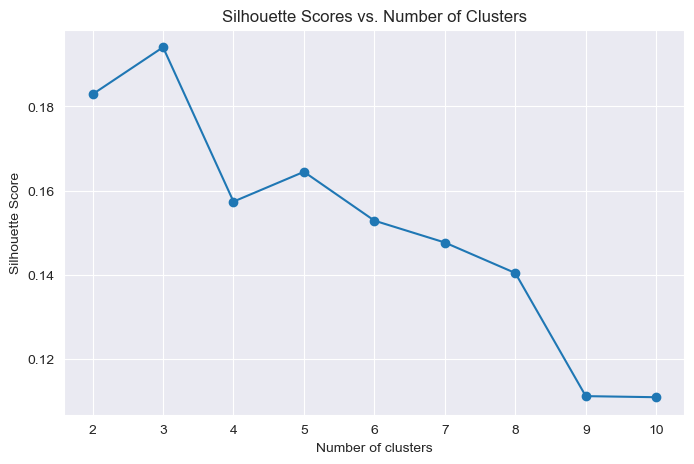

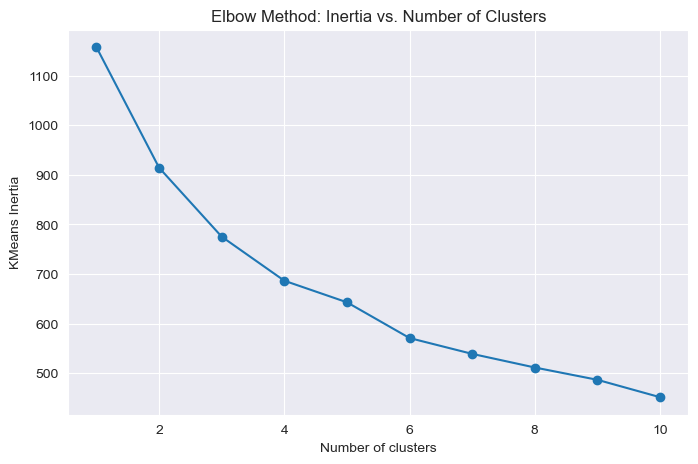

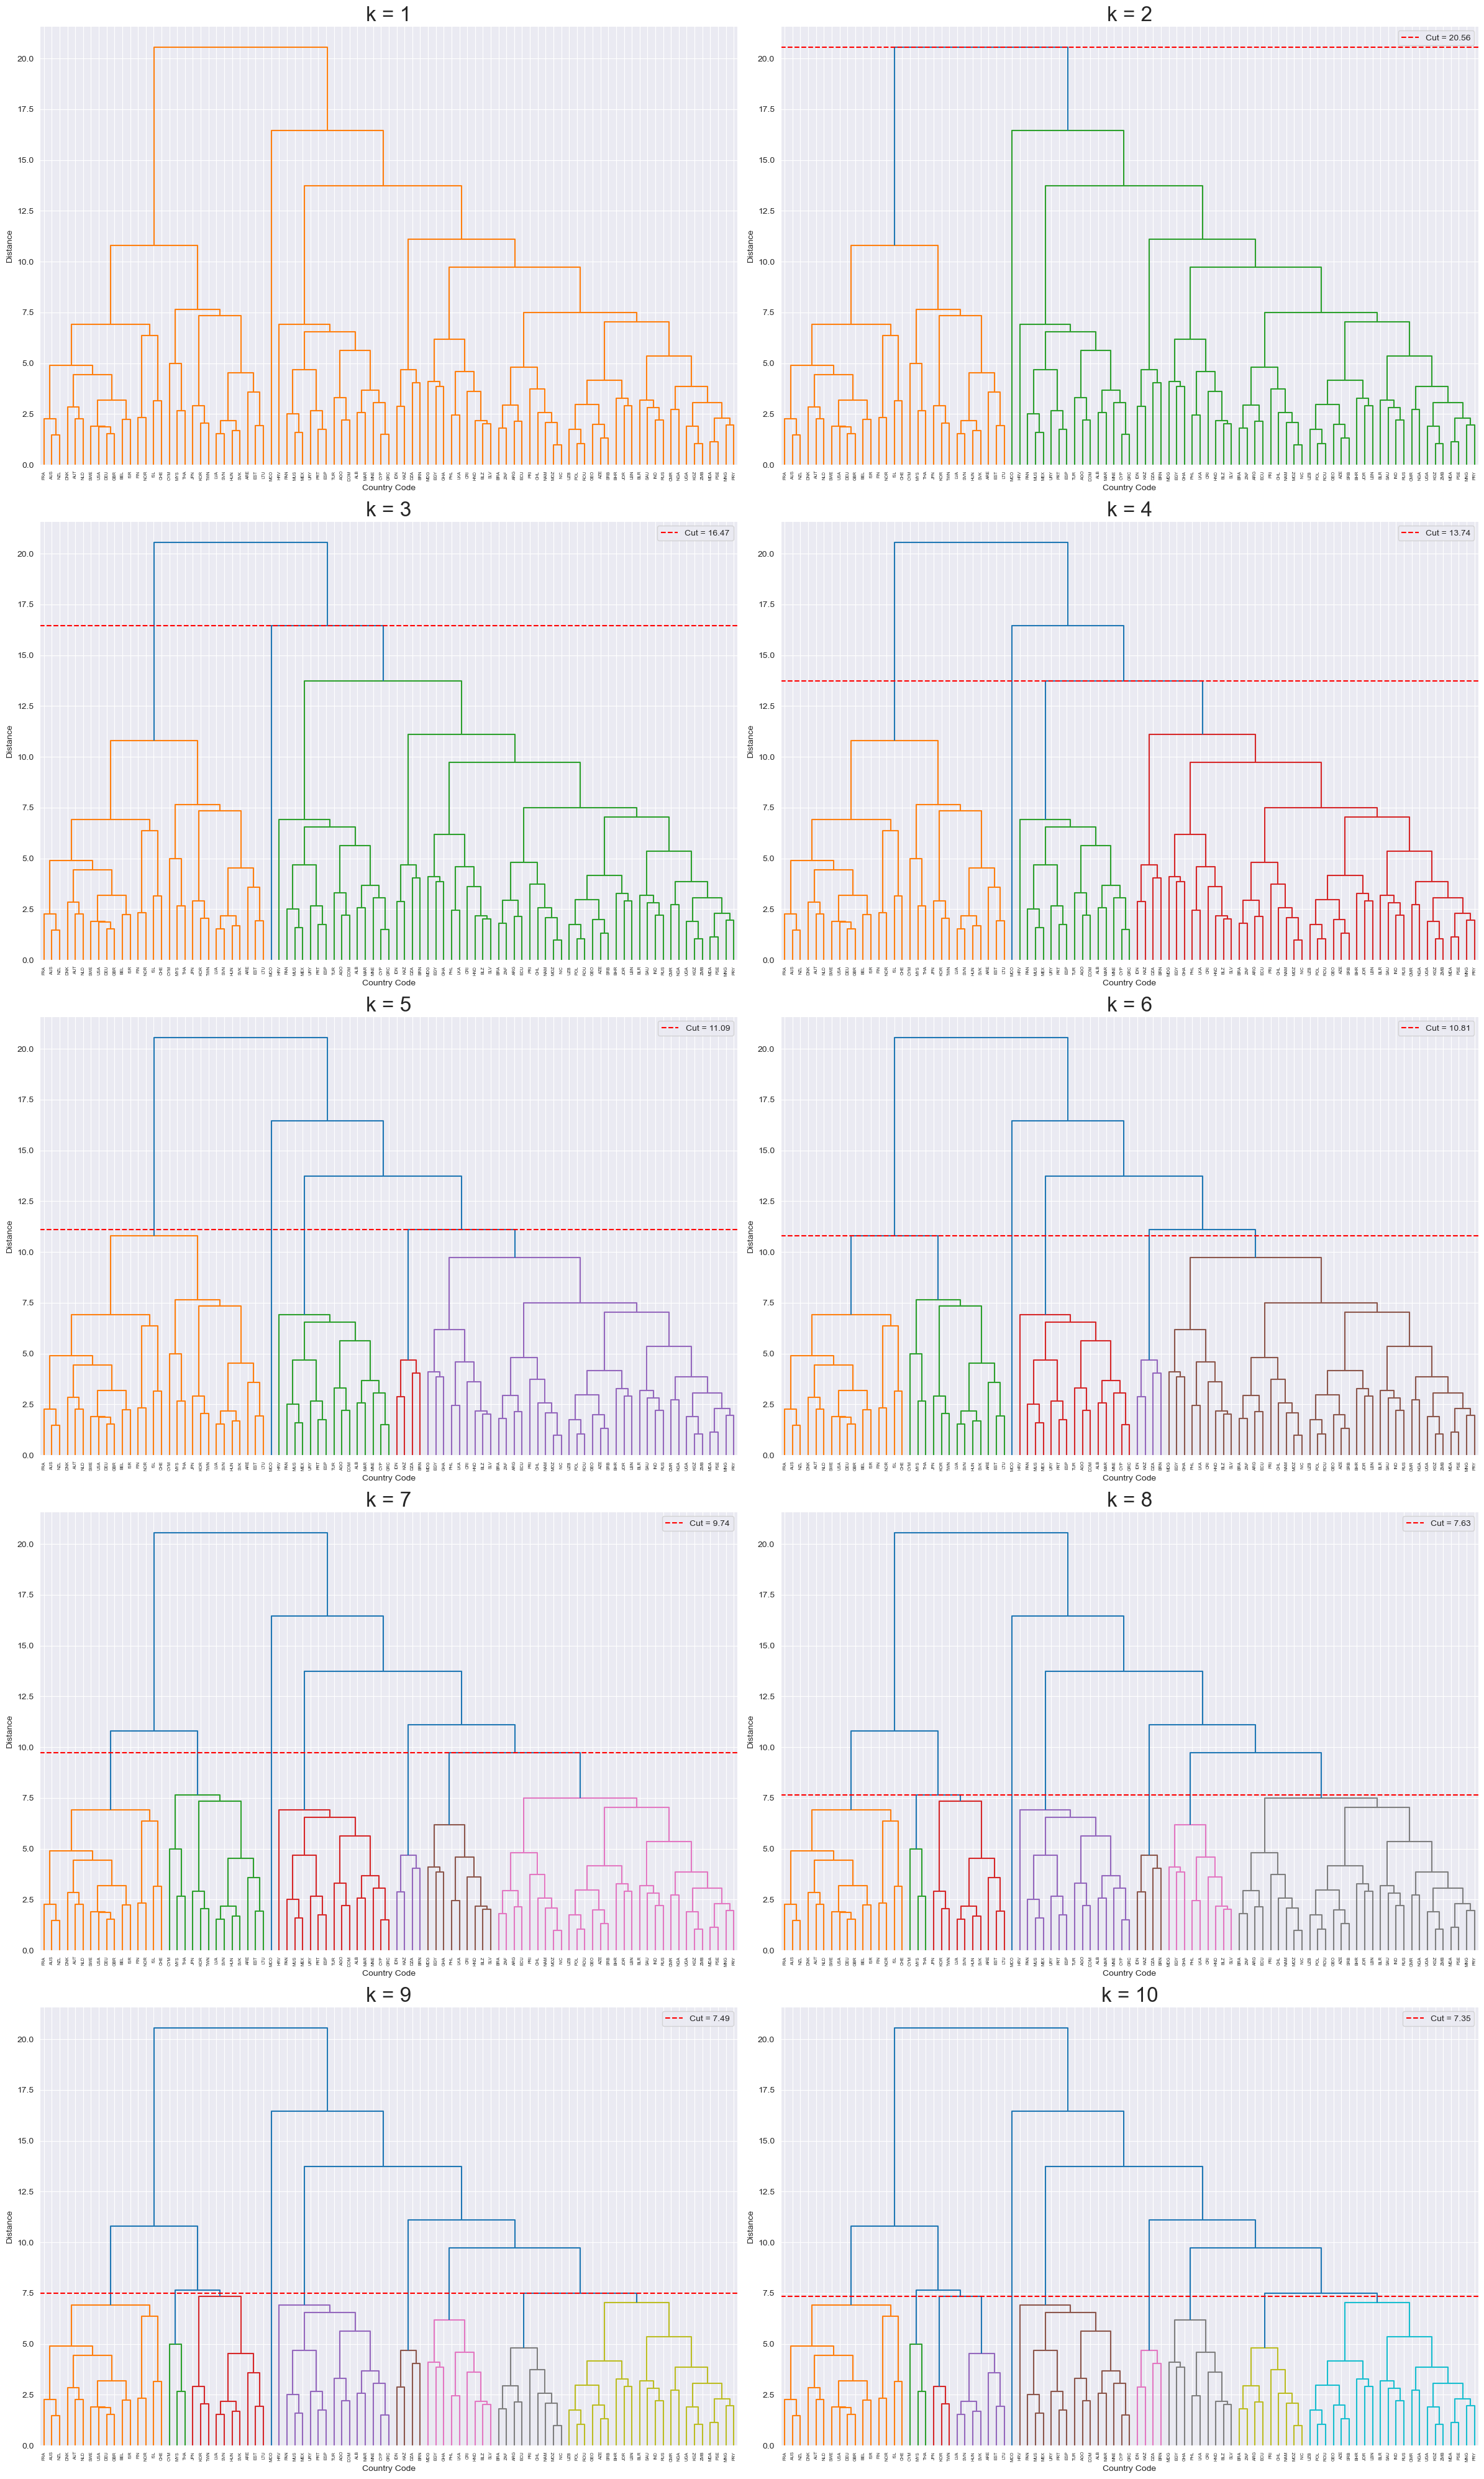

In [5]:
df_all = pd.read_csv("../Data/final_cleaned_dataset.csv")
df_all = df_all.drop(columns=["Unnamed: 0"], errors='ignore')

# Extract country-related columns
countries = df_all[["CountryName", "CountryCode"]]
# The remaining features
X_full = df_all.drop(columns=["CountryName", "CountryCode"])

# Load Spearman correlation and p‑value matrices (indexed by feature name)
spearman_corr_df = pd.read_csv("../Data/spearman_correlations.csv", index_col=0)
spearman_pval_df = pd.read_csv("../Data/spearman_pvalues.csv", index_col=0)

# Features to drop
features_to_drop = {'CostOfLivingIndex', 'ReverseTrafficIndex', 'QualityOfLifeIndex', 'ReverseTrafficInefficiencyIndex',
                    'ReverseTrafficTimeIndexMinutes'}

# And if you want to apply this after automated feature selection:
X_full = manual_feature_drop(X_full, features_to_drop)

# Feature selection (adjust thresholds as needed)
X_selected, selected_features = remove_redundant_features(X_full,
                                                          corr_df=spearman_corr_df,
                                                          pval_df=spearman_pval_df,
                                                          corr_threshold=0.8,
                                                          pval_threshold=0.05)

# Plot Silhouette and Elbow methods to aid in choosing the number of clusters
silhouette_scores = plot_silhouette_scores(X_selected, k_range=range(2, 11))
inertias = plot_elbow_method(X_selected, k_range=range(1, 11))

# Plot multiple dendrograms for k = 1 to 10 to visually compare cluster separations
plot_multiple_dendrograms(X_selected, countries=countries, max_k=10)

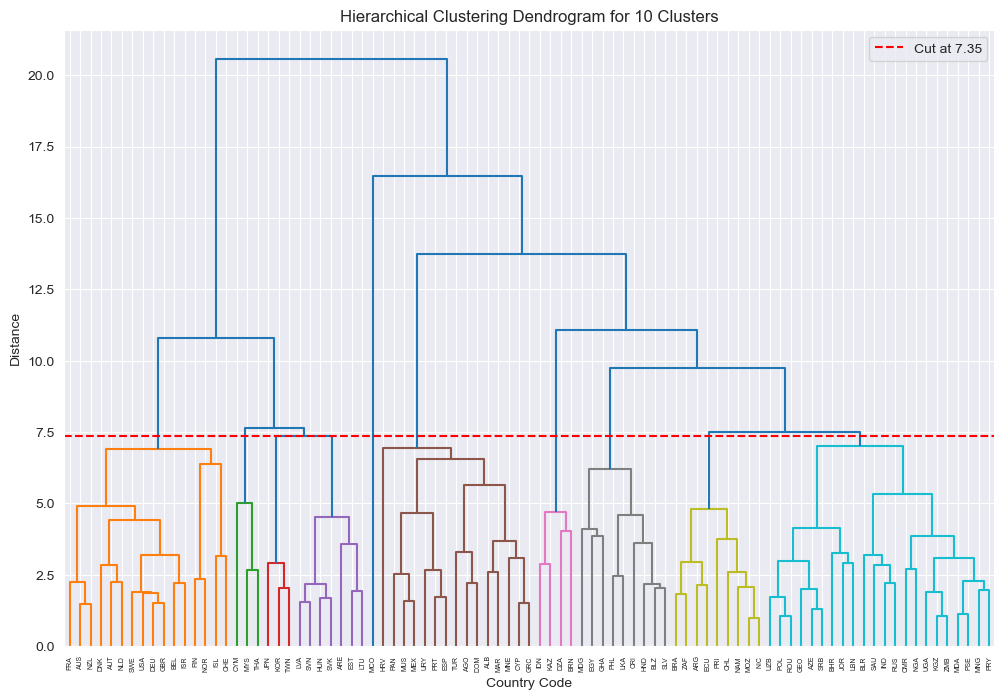

D:\Anaconda\lib\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
D:\Anaconda\lib\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
D:\Anaconda\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


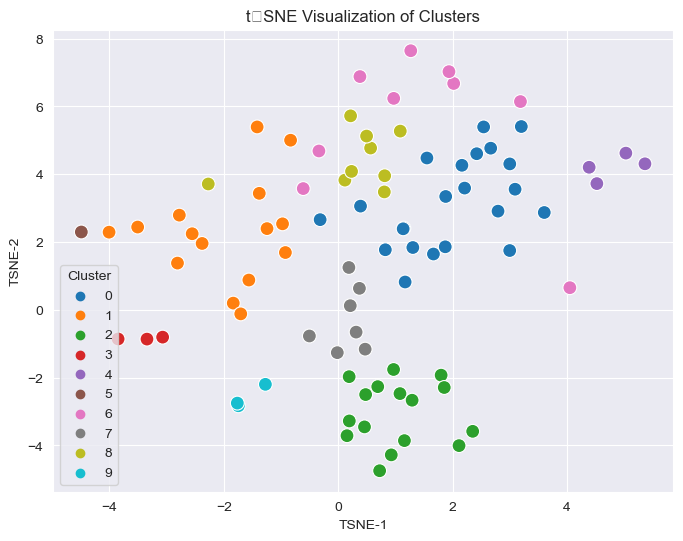

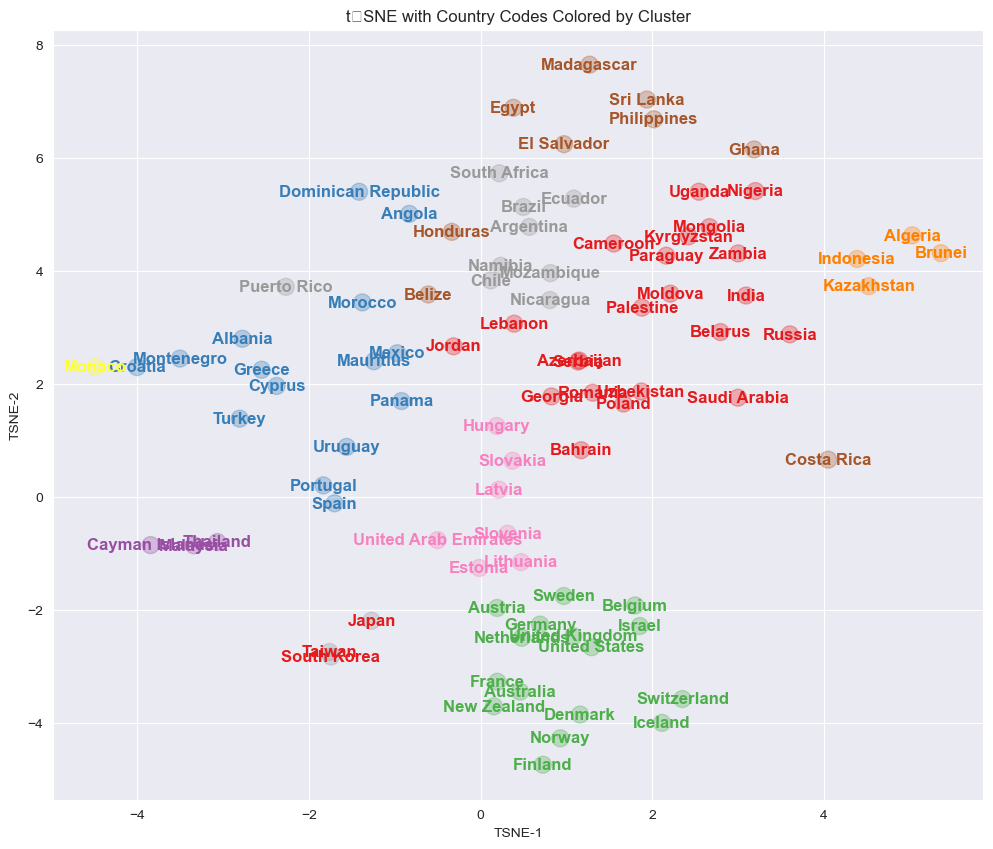

Validation Indices:
Davies-Bouldin Index: 1.3419928625502973
Calinski-Harabasz Index: 13.100710506565765
Dunn Index: 0.23193021798693242
Cluster mapping:
Cluster 0: Azerbaijan, Bahrain, Belarus, Cameroon, Georgia, India, Jordan, Kyrgyzstan, Lebanon, Moldova, Mongolia, Nigeria, Palestine, Paraguay, Poland, Romania, Russia, Saudi Arabia, Serbia, Uganda, Uzbekistan, Zambia
Cluster 1: Albania, Angola, Croatia, Cyprus, Dominican Republic, Greece, Mauritius, Mexico, Montenegro, Morocco, Panama, Portugal, Spain, Turkey, Uruguay
Cluster 2: Australia, Austria, Belgium, Denmark, Finland, France, Germany, Iceland, Israel, Netherlands, New Zealand, Norway, Sweden, Switzerland, United Kingdom, United States
Cluster 3: Cayman Islands, Malaysia, Thailand
Cluster 4: Algeria, Brunei, Indonesia, Kazakhstan
Cluster 5: Monaco
Cluster 6: Belize, Costa Rica, Egypt, El Salvador, Ghana, Honduras, Madagascar, Philippines, Sri Lanka
Cluster 7: Estonia, Hungary, Latvia, Lithuania, Slovakia, Slovenia, United Arab

In [6]:
k_opt = 10
# Perform hierarchical clustering on the selected features using a chosen k
df_combined, cluster_labels, validation_indices = run_clustering_analysis(
    X_selected,
    countries=countries,
    k_clusters=k_opt,
    plot_dendrogram_flag=True,
    plot_tsne_flag=True,
    compute_validation=True
)
    

PCA applied. Explained variance ratios: [0.29943729 0.22850855 0.10290997 0.07197552 0.05958885 0.05167885
 0.04468503 0.04180968]


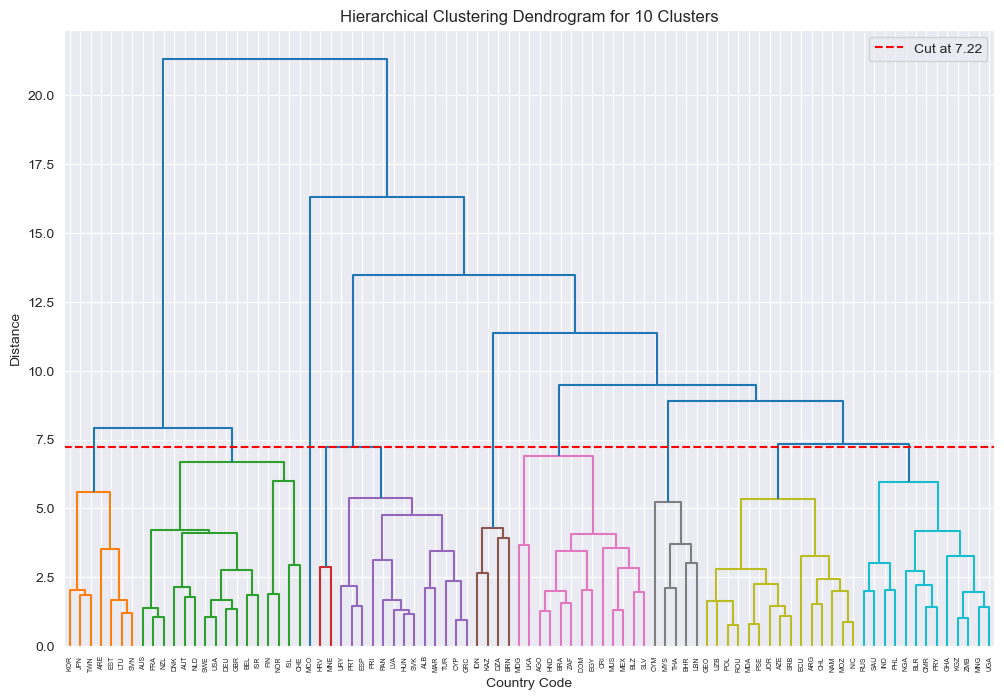

D:\Anaconda\lib\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
D:\Anaconda\lib\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
D:\Anaconda\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


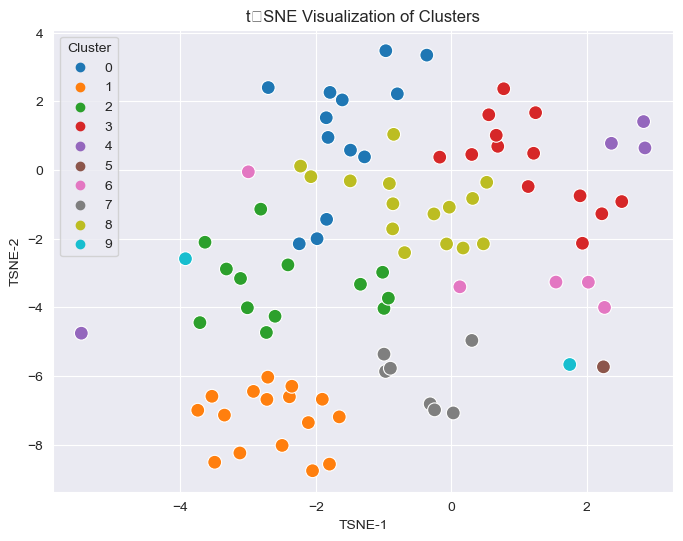

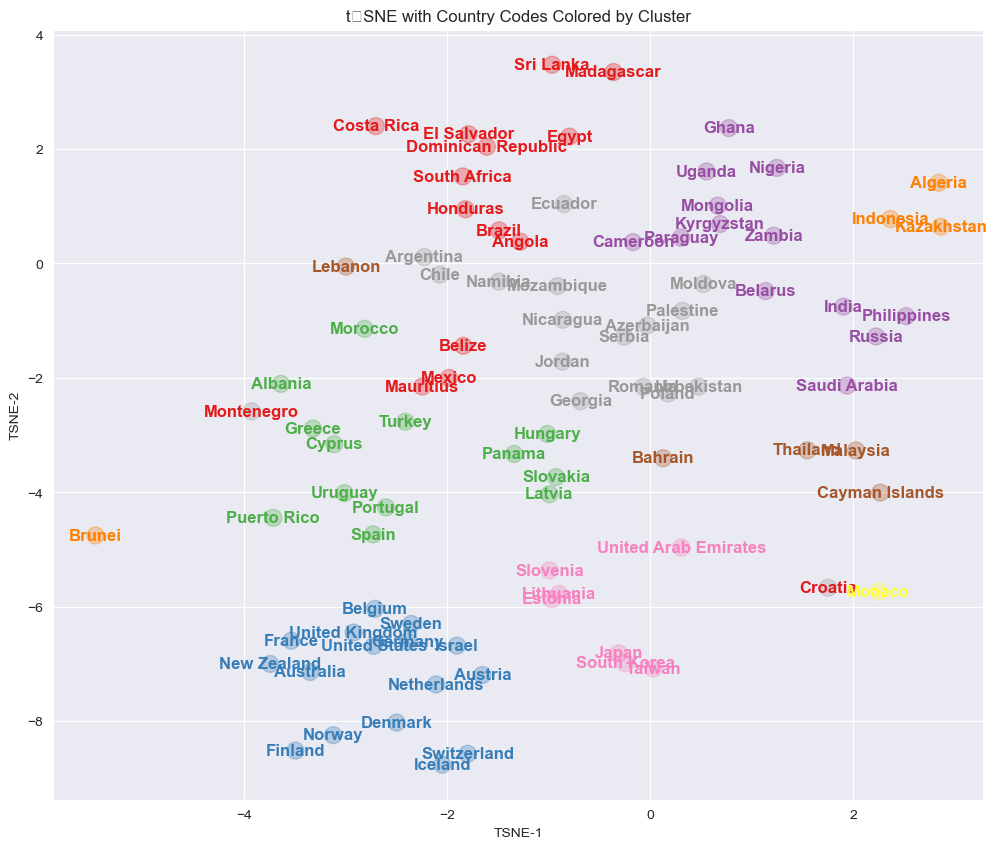

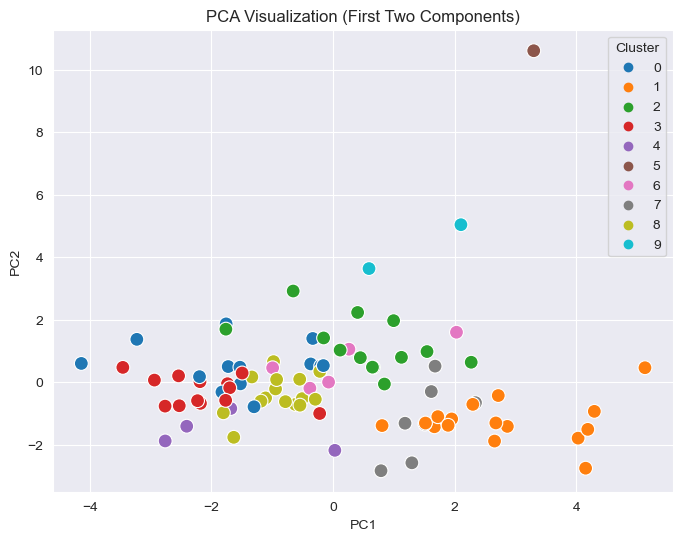

Validation Indices:
Davies-Bouldin Index: 1.342384972711414
Calinski-Harabasz Index: 16.770048494914928
Dunn Index: 0.22560548288992996
Cluster mapping:
Cluster 0: Angola, Belize, Brazil, Costa Rica, Dominican Republic, Egypt, El Salvador, Honduras, Madagascar, Mauritius, Mexico, South Africa, Sri Lanka
Cluster 1: Australia, Austria, Belgium, Denmark, Finland, France, Germany, Iceland, Israel, Netherlands, New Zealand, Norway, Sweden, Switzerland, United Kingdom, United States
Cluster 2: Albania, Cyprus, Greece, Hungary, Latvia, Morocco, Panama, Portugal, Puerto Rico, Slovakia, Spain, Turkey, Uruguay
Cluster 3: Belarus, Cameroon, Ghana, India, Kyrgyzstan, Mongolia, Nigeria, Paraguay, Philippines, Russia, Saudi Arabia, Uganda, Zambia
Cluster 4: Algeria, Brunei, Indonesia, Kazakhstan
Cluster 5: Monaco
Cluster 6: Bahrain, Cayman Islands, Lebanon, Malaysia, Thailand
Cluster 7: Estonia, Japan, Lithuania, Slovenia, South Korea, Taiwan, United Arab Emirates
Cluster 8: Argentina, Azerbaijan, C

(       CountryName CountryCode       PC1       PC2       PC3       PC4  \
 0          Albania         ALB -0.655931  2.915129 -0.329703  0.919829   
 1          Algeria         DZA -2.759492 -1.882008  2.634044  3.510042   
 2           Angola         AGO -1.723883  0.498081 -0.934782  0.482869   
 3        Argentina         ARG -0.620013 -0.713990 -1.791733  0.768243   
 4        Australia         AUS  2.654129 -1.885460 -1.292411  0.841218   
 ..             ...         ...       ...       ...       ...       ...   
 84  United Kingdom         GBR  1.721719 -1.103896 -0.729312  0.484743   
 85   United States         USA  1.890968 -1.381707 -0.762682  0.079686   
 86         Uruguay         URY  1.124003  0.793984 -1.721253  0.194613   
 87      Uzbekistan         UZB -0.782921 -0.624175  0.179088 -0.305728   
 88          Zambia         ZMB -1.765898 -0.582527  0.713766  0.893134   
 
          PC5       PC6       PC7       PC8  Cluster    TSNE-1    TSNE-2  
 0  -0.135208 -0.778463

In [7]:
k_opt = 10
run_clustering_analysis(
    X_selected,
    countries=countries,
    k_clusters=k_opt,
    use_pca=True,
    pca_components=0.9,
    plot_dendrogram_flag=True,
    plot_tsne_flag=True,
    plot_pca_flag=True,
    compute_validation=True
)

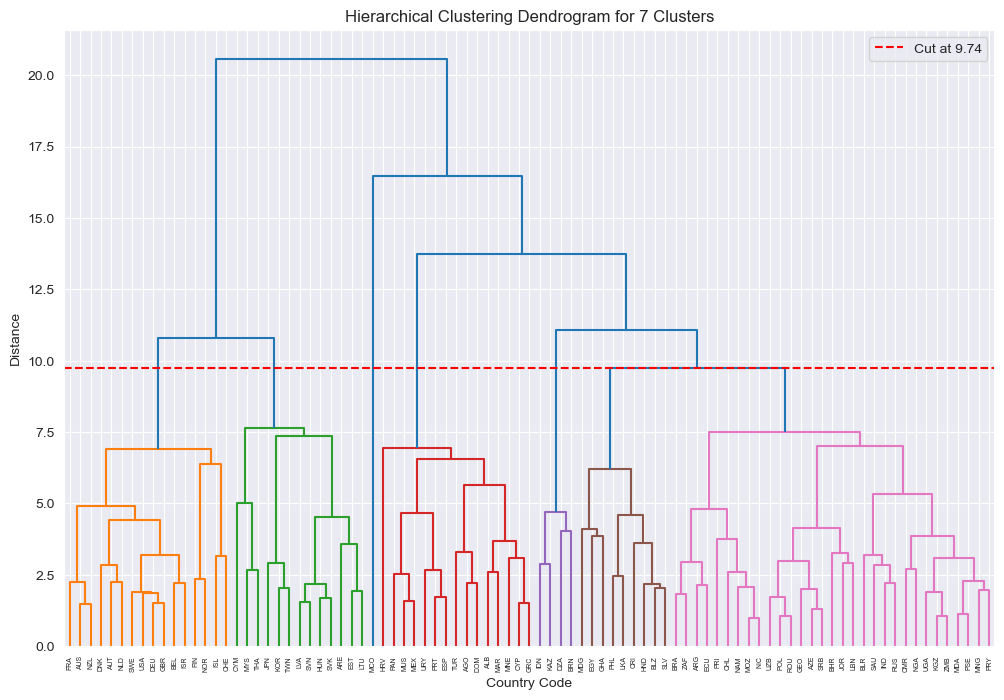

D:\Anaconda\lib\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
D:\Anaconda\lib\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
D:\Anaconda\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


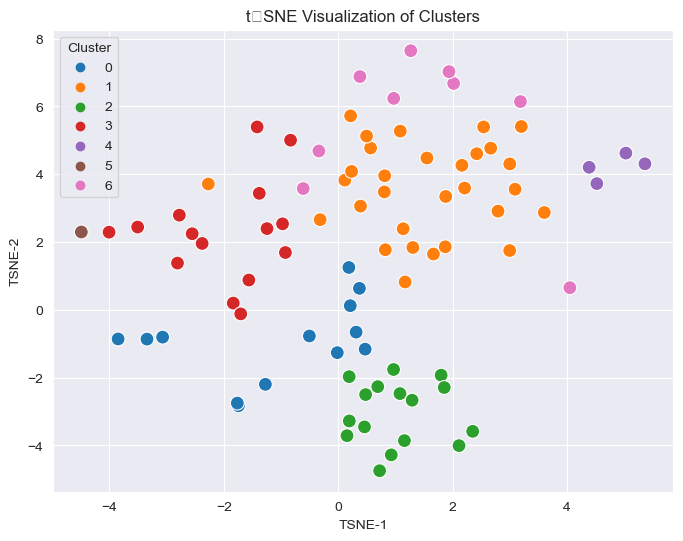

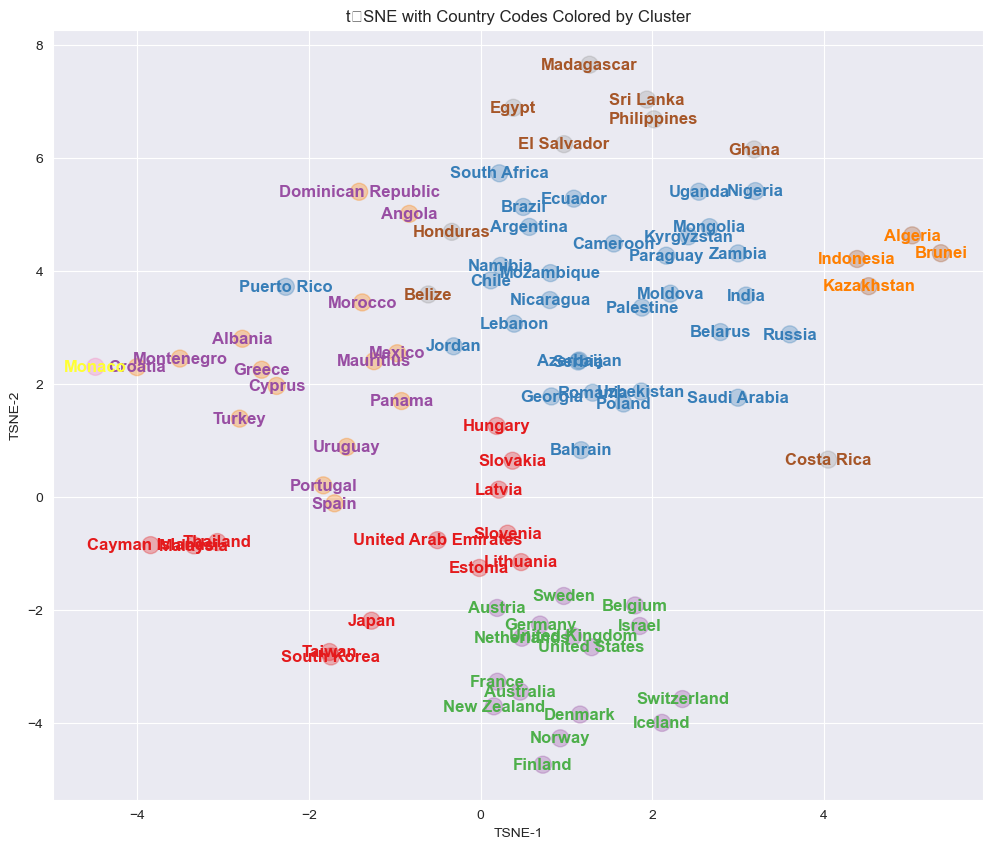

Validation Indices:
Davies-Bouldin Index: 1.4542252946545642
Calinski-Harabasz Index: 15.167285415210339
Dunn Index: 0.23193021798693242
Cluster mapping:
Cluster 0: Cayman Islands, Estonia, Hungary, Japan, Latvia, Lithuania, Malaysia, Slovakia, Slovenia, South Korea, Taiwan, Thailand, United Arab Emirates
Cluster 1: Argentina, Azerbaijan, Bahrain, Belarus, Brazil, Cameroon, Chile, Ecuador, Georgia, India, Jordan, Kyrgyzstan, Lebanon, Moldova, Mongolia, Mozambique, Namibia, Nicaragua, Nigeria, Palestine, Paraguay, Poland, Puerto Rico, Romania, Russia, Saudi Arabia, Serbia, South Africa, Uganda, Uzbekistan, Zambia
Cluster 2: Australia, Austria, Belgium, Denmark, Finland, France, Germany, Iceland, Israel, Netherlands, New Zealand, Norway, Sweden, Switzerland, United Kingdom, United States
Cluster 3: Albania, Angola, Croatia, Cyprus, Dominican Republic, Greece, Mauritius, Mexico, Montenegro, Morocco, Panama, Portugal, Spain, Turkey, Uruguay
Cluster 4: Algeria, Brunei, Indonesia, Kazakhstan

In [57]:
k_opt = 7
# Perform hierarchical clustering on the selected features using a chosen k
df_combined, cluster_labels, validation_indices = run_clustering_analysis(
    X_selected,
    countries=countries,
    k_clusters=k_opt,
    plot_dendrogram_flag=True,
    plot_tsne_flag=True,
    compute_validation=True
)

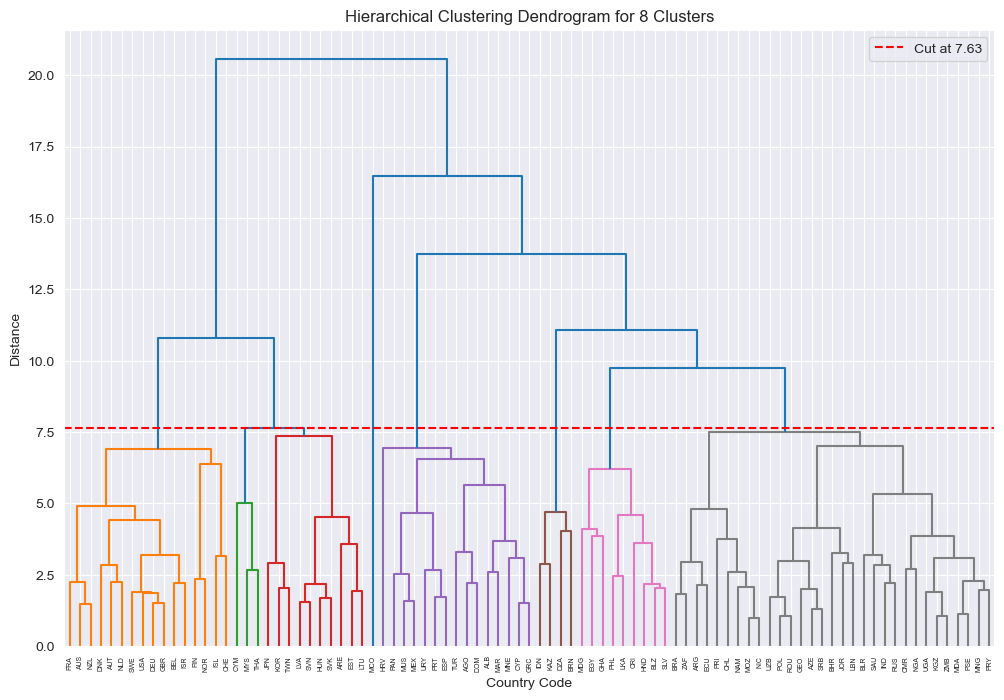

D:\Anaconda\lib\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
D:\Anaconda\lib\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
D:\Anaconda\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


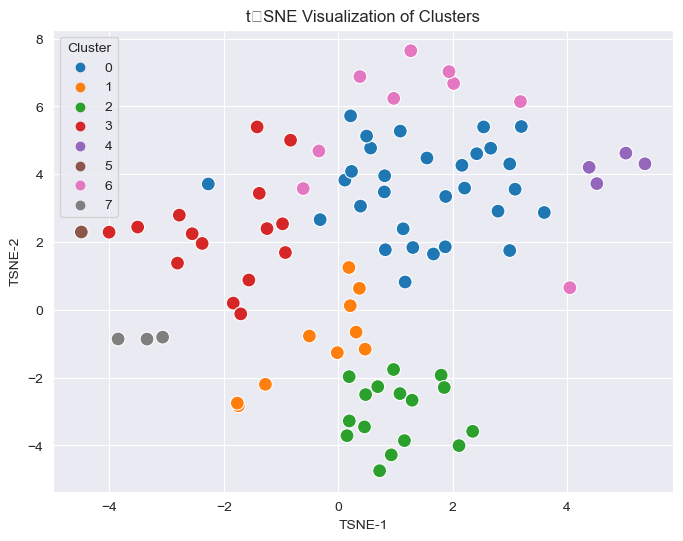

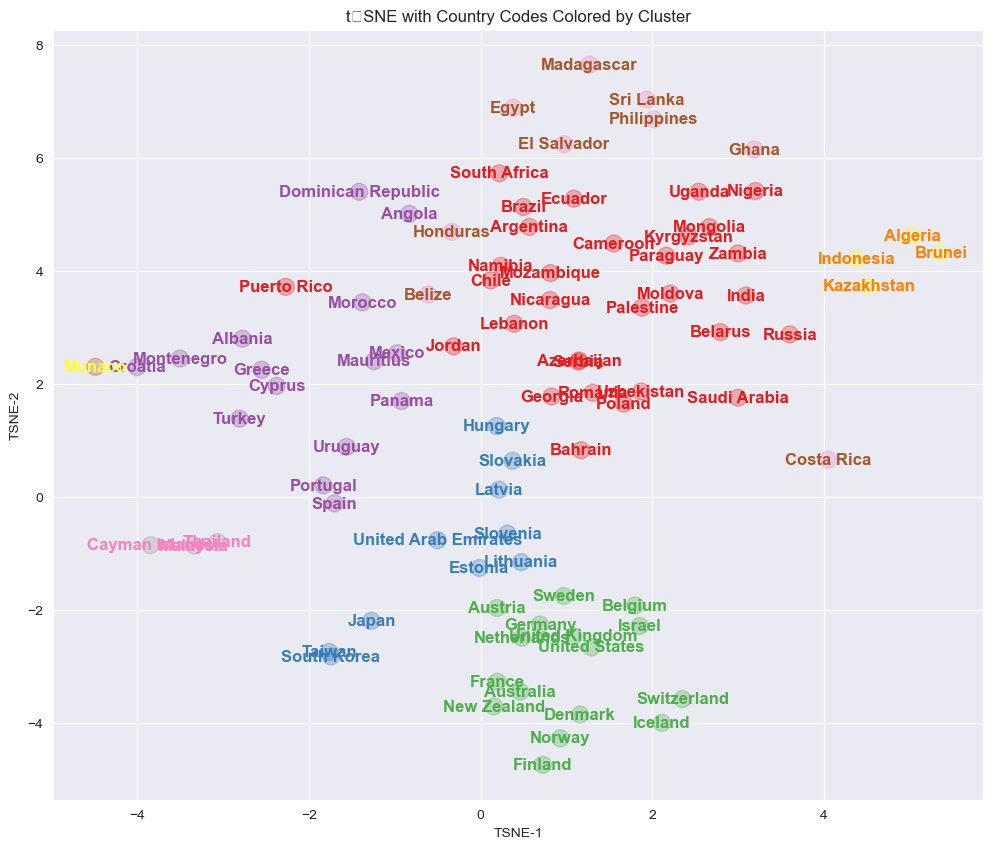

Validation Indices:
Davies-Bouldin Index: 1.4370464174225348
Calinski-Harabasz Index: 14.212002093914206
Dunn Index: 0.23193021798693242
Cluster mapping:
Cluster 0: Argentina, Azerbaijan, Bahrain, Belarus, Brazil, Cameroon, Chile, Ecuador, Georgia, India, Jordan, Kyrgyzstan, Lebanon, Moldova, Mongolia, Mozambique, Namibia, Nicaragua, Nigeria, Palestine, Paraguay, Poland, Puerto Rico, Romania, Russia, Saudi Arabia, Serbia, South Africa, Uganda, Uzbekistan, Zambia
Cluster 1: Estonia, Hungary, Japan, Latvia, Lithuania, Slovakia, Slovenia, South Korea, Taiwan, United Arab Emirates
Cluster 2: Australia, Austria, Belgium, Denmark, Finland, France, Germany, Iceland, Israel, Netherlands, New Zealand, Norway, Sweden, Switzerland, United Kingdom, United States
Cluster 3: Albania, Angola, Croatia, Cyprus, Dominican Republic, Greece, Mauritius, Mexico, Montenegro, Morocco, Panama, Portugal, Spain, Turkey, Uruguay
Cluster 4: Algeria, Brunei, Indonesia, Kazakhstan
Cluster 5: Monaco
Cluster 6: Belize

In [58]:
k_opt = 8
# Perform hierarchical clustering on the selected features using a chosen k
df_combined, cluster_labels, validation_indices = run_clustering_analysis(
    X_selected,
    countries=countries,
    k_clusters=k_opt,
    plot_dendrogram_flag=True,
    plot_tsne_flag=True,
    compute_validation=True
)